# Trabalho Final - notebook base do projeto da Ana Carolina

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Pergunta de pesquisa

#### **Quais características são mais comuns nos acidentes graves e fatais?**

(causa do acidente, tipo de acidente, fase do dia, condição meteorológica)

--- Breve explicação do problema, qual conjunto de dados será utilizado e o que se pretende estudar/avaliar no trabalho.

In [2]:
df = pd.read_csv("../datasets/ana_carolina/datatran2017-2024.zip", compression='zip', encoding='latin-1', sep=';')

df.head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,17,01/01/2017,domingo,01:45:00,RS,116,"34,9",VACARIA,Defeito Mecânico no Veículo,Colisão traseira,...,0,2,0,4,2,"-28,5071196","-50,941176",SPRF-RS,DEL05-RS,UOP03-DEL05-RS
1,20,01/01/2017,domingo,01:00:00,PR,376,636,TIJUCAS DO SUL,Velocidade Incompatível,Saída de leito carroçável,...,0,1,0,0,2,"-25,754","-49,1266",SPRF-PR,DEL01-PR,DEL7/1-UOP08/PR
2,69,01/01/2017,domingo,04:40:00,BA,101,65,ENTRE RIOS,Condutor Dormindo,Colisão frontal,...,1,2,0,2,2,"-11,9618","-38,0953",SPRF-BA,DEL01-BA,UOP04-DEL01-BA
3,106,01/01/2017,domingo,06:30:00,PA,316,"72,5",CASTANHAL,Falta de Atenção à Condução,Colisão lateral,...,0,3,0,0,3,"-1,2899799","-47,83483207",SPRF-PA,DEL01-PA,DEL19/1-UOP02/PA
4,109,01/01/2017,domingo,09:00:00,GO,20,"220,5",POSSE,Defeito na Via,Colisão com objeto estático,...,1,0,1,3,2,"-14,14220931","-46,32258922",SPRF-DF,DEL02-DF,UOP03-DEL02-DF


In [3]:
df.columns

Index(['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km',
       'municipio', 'causa_acidente', 'tipo_acidente',
       'classificacao_acidente', 'fase_dia', 'sentido_via',
       'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo',
       'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos',
       'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional',
       'delegacia', 'uop'],
      dtype='str')

## Classificação das variáveis associadas à pergunta de pesquisa

In [4]:
df["causa_acidente"].unique()

<StringArray>
[                                                   'Defeito Mecânico no Veículo',
                                                        'Velocidade Incompatível',
                                                              'Condutor Dormindo',
                                                    'Falta de Atenção à Condução',
                                                                 'Defeito na Via',
                                                             'Ingestão de Álcool',
                                             'Não guardar distância de segurança',
                                                             'Pista Escorregadia',
                                                   'Falta de Atenção do Pedestre',
                              'Desobediência às normas de trânsito pelo condutor',
                                                          'Fenômenos da Natureza',
                                                               'Animais n

A causa do acidente é uma variável **categórica** e possui 91 categorias.

In [5]:
df["tipo_acidente"].unique()

<StringArray>
[               'Colisão traseira',       'Saída de leito carroçável',
                 'Colisão frontal',                 'Colisão lateral',
     'Colisão com objeto estático',                      'Tombamento',
 'Colisão com objeto em movimento',           'Derramamento de carga',
       'Atropelamento de Pedestre',             'Colisão transversal',
                        'Incêndio',                     'Capotamento',
         'Atropelamento de Animal',                   'Engavetamento',
                 'Danos eventuais',    'Queda de ocupante de veículo',
              'Colisão com objeto',                               nan,
   'Colisão lateral mesmo sentido',                'Eventos atípicos',
  'Colisão lateral sentido oposto',    'Sinistro pessoal de trânsito']
Length: 22, dtype: str

O tipo do acidente é uma variável **categórica** e possui 22 categorias.

In [6]:
df["fase_dia"].unique()

<StringArray>
['Plena Noite', 'Amanhecer', 'Pleno dia', 'Anoitecer']
Length: 4, dtype: str

A fase do dia é uma variável **categórica** e possui 4 categorias.

In [7]:
df["condicao_metereologica"].unique()

<StringArray>
[       'Céu Claro',   'Garoa/Chuvisco',          'Nublado',
              'Sol',            'Chuva', 'Nevoeiro/Neblina',
         'Ignorado',            'Vento',          'Granizo',
             'Neve']
Length: 10, dtype: str

A condição meteorológica é uma variável **categórica** e possui 10 caategorias.

In [8]:
df["classificacao_acidente"].unique()

<StringArray>
['Com Vítimas Feridas', 'Com Vítimas Fatais', nan, 'Sem Vítimas']
Length: 4, dtype: str

A classificação do acidente é uma variável **categórica** e possui 4 categorias.

In [9]:
df["feridos_graves"].unique()

array([ 0,  1,  2,  3,  4,  9,  6,  5,  7, 10,  8, 16, 21, 28, 17, 12, 22,
       13, 15, 18, 20, 11, 19, 23, 26, 31, 14, 29, 24, 30])

Feridos graves é uma variável **numérica** e varia de 0 a 30 no dataset.

In [10]:
df["mortos"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  8, 21,  7, 11,  9, 10, 13, 12, 19, 23])

Mortos é uma variável **numérica** e varia de 0 a 23 no dataset.

## Verificando a qualidade dos dados

In [11]:
# Verificando se há duplicatas

df.duplicated().sum()

np.int64(0)

In [12]:
# Se houver dados duplicados, verificamos quais são:

df[df.duplicated()]

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop


**Conclusão 1:** não há duplicatas no dataset analisado.

In [13]:
# Verificando se há valores faltantes

dados_faltantes_soma = df.isnull().sum()
dados_faltantes_porc = df.isnull().mean() * 100

df_dados_faltantes = pd.DataFrame({"Dados faltantes (soma)": dados_faltantes_soma, "Dados faltantes (porcentagem)": dados_faltantes_porc})
df_dados_faltantes

,Dados faltantes (soma),Dados faltantes (porcentagem)
id,0,0.000000
data_inversa,0,0.000000
dia_semana,0,0.000000
horario,0,0.000000
uf,0,0.000000
br,0,0.000000
km,0,0.000000
municipio,0,0.000000
causa_acidente,0,0.000000
tipo_acidente,41,0.007491


**Conclusão 2:** Há valores faltantes em 5 colunas do dataset, mas apenas 2 delas são pertinentes à pergunta de pesquisa e merecem atenção neste momento. Temos 41 dados faltantes da variável tipo_acidente e 9 da variável classificacao_acidente. Mas, comparando com o restante dos dados das colunas, temos que esses dados faltantes representam menos de 0.01% em cada coluna, ou seja, são de pouca importância para a análise, poderíamos apagá-los para uma análise mais limpa do dataset.

## Limpeza do conjunto de dados

In [14]:
# Se houver duplicatas, remove a linha inteira que estiver duplicada
df = df.drop_duplicates()

In [15]:
# Apaga as linhas com valores faltantes das variáveis tipo_acidente e classificacao_acidente
df = df.dropna(subset=["tipo_acidente", "classificacao_acidente"])

In [16]:
# Verifica se ainda há valores faltantes nas colunas de interesse

dados_faltantes_soma = df.isnull().sum()
dados_faltantes_porc = df.isnull().mean() * 100

df_dados_faltantes = pd.DataFrame({"Dados faltantes (soma)": dados_faltantes_soma, "Dados faltantes (porcentagem)": dados_faltantes_porc})
df_dados_faltantes

,Dados faltantes (soma),Dados faltantes (porcentagem)
id,0,0.000000
data_inversa,0,0.000000
dia_semana,0,0.000000
horario,0,0.000000
uf,0,0.000000
br,0,0.000000
km,0,0.000000
municipio,0,0.000000
causa_acidente,0,0.000000
tipo_acidente,0,0.000000


**Conclusão 3:** Na limpeza do dataset, portanto, apenas apaguei as linhas que tinham dados faltantes para tipo_acidente ou classificacao_acidente.

## Estatística descritiva

Utiliza as variáveis categóricas e numéricas identificadas no início do trabalho para calcular estatísticas descritivas pertinentes à pergunta de pesquisa.

In [17]:
df_med_causa_ac = df.groupby("causa_acidente")[["feridos_graves", "mortos"]].mean()

print(df_med_causa_ac.max())
print("################################")

print(df_med_causa_ac.idxmax())
print("################################")

print(df_med_causa_ac.min())
print("################################")

print(df_med_causa_ac.idxmin())

**Conclusão 4:** A pergunta de pesquisa busca identificar as características mais comuns em acidentes graves e fatais. Logo, já sabemos, a partir dos resultados acima, que acidentes cuja causa é Sistema de drenagem ineficiente possui a maior média de feridos graves (0.6) enquanto que os acidentes cuja causa é suicídio (presumido) tem a maior média de mortos (0.48). Além disso, Obstrução Via tentativa Assalto é a causa de acidentes que, em média, possui menos feridos graves e mortos.

In [18]:
df_med_tipo_ac = df.groupby("tipo_acidente")[["feridos_graves", "mortos"]].mean()

print(df_med_tipo_ac.max())
print("################################")

print(df_med_tipo_ac.idxmax())
print("################################")

print(df_med_tipo_ac.min())
print("################################")

print(df_med_tipo_ac.idxmin())

**Conclusão 5:** A partir dos resultados acima, temos que colisão frontal é o tipo de acidente que, em média, tem mais feridos graves e mortos. Enquanto incêndio tem as menores médias tanto de feridos graves quanto de mortos.

In [19]:
df_med_fase_dia = df.groupby("fase_dia")[["feridos_graves", "mortos"]].mean()

print(df_med_fase_dia.max())
print("################################")

print(df_med_fase_dia.idxmax())
print("################################")

print(df_med_fase_dia.min())
print("################################")

print(df_med_fase_dia.idxmin())

feridos_graves    0.290143
mortos            0.118323
dtype: float64
################################
feridos_graves    Plena Noite
mortos              Amanhecer
dtype: str
################################
feridos_graves    0.242336
mortos            0.057316
dtype: float64
################################
feridos_graves    Pleno dia
mortos            Pleno dia
dtype: str


**Conclusão 6:** Diante dos resultados acima, temos que Plena Noite é a fase do dia que, em média, tem mais feridos graves, enquanto Amanhecer tem mais mortos. Pleno dia apresenta as menores médias tanto para feridos graves quanto para mortos.

In [20]:
df_med_cond_met = df.groupby("condicao_metereologica")[["feridos_graves", "mortos"]].mean()

print(df_med_cond_met.max())
print("################################")

print(df_med_cond_met.idxmax())
print("################################")

print(df_med_cond_met.min())
print("################################")

print(df_med_cond_met.idxmin())

feridos_graves    0.319985
mortos            0.135604
dtype: float64
################################
feridos_graves            Ignorado
mortos            Nevoeiro/Neblina
dtype: str
################################
feridos_graves    0.1
mortos            0.0
dtype: float64
################################
feridos_graves    Neve
mortos            Neve
dtype: str


**Conclusão 7:** Diante dos resultados acima, temos que a média de mortos é maior quando o acidente ocorre em meio a nevoeiro/neblina. Além do mais, quase não há mortos nem feridos em meio a neve.

In [21]:
df_med_classif_ac = df.groupby("classificacao_acidente")[["feridos_graves", "mortos"]].mean()

print(df_med_classif_ac.max())
print("################################")

print(df_med_classif_ac.idxmax())
print("################################")

print(df_med_classif_ac.min())
print("################################")

print(df_med_classif_ac.idxmin())

**Conclusão 8:** Os resultados acima só dizem que quando o acidente é classificado como "Sem vítimas" não há nenhum morto nem ferido grave (como esperado pela definição) e quando é classificado como "Com vítimas fatais" tem média de 1.17 mortos, ou seja, mais de 1 por acidente.

**Conclusão 9:** Apenas observando médias, máximos e mínimos na estatística descritiva, já conseguimos inferir que acidentes com mais feridos graves e mortos costumam ter como causa Sistema de drenagem ineficiente ou suicídio (presumido), são do tipo colisão frontal, ocorrem a noite ou ao amanhecer e em meio a nevoeiro/neblina.

## Análise Exploratória

(apenas um "gostinho" no workshop de 29/08 pois isso será explorado no próximo encontro)

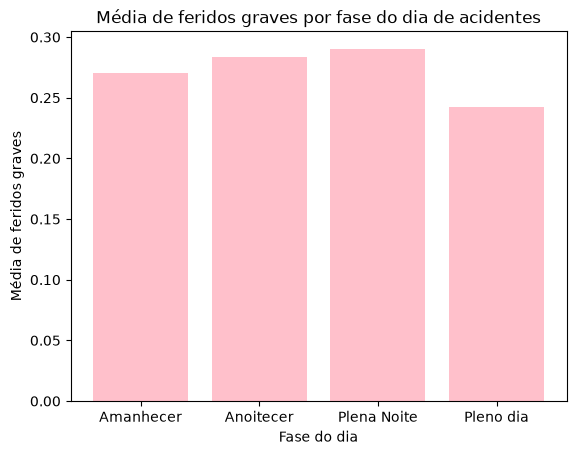

In [22]:
# gráfico de barras

plt.bar(df_med_fase_dia.index, df_med_fase_dia["feridos_graves"], color="pink")
plt.title("Média de feridos graves por fase do dia de acidentes")
plt.xlabel("Fase do dia")
plt.ylabel("Média de feridos graves")
plt.show()

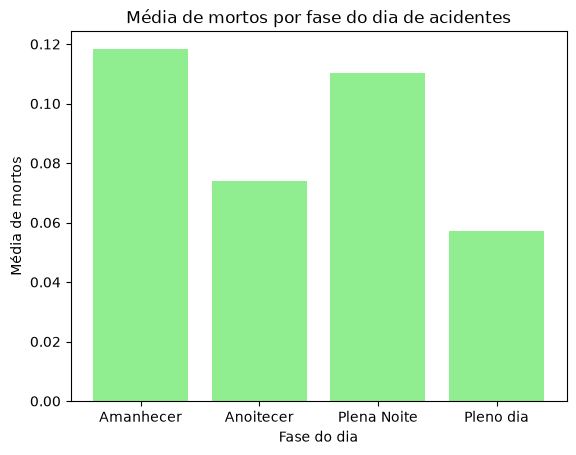

In [23]:
plt.bar(df_med_fase_dia.index, df_med_fase_dia["mortos"], color="lightgreen")
plt.title("Média de mortos por fase do dia de acidentes")
plt.xlabel("Fase do dia")
plt.ylabel("Média de mortos")
plt.show()